# Notebook that integrates correlation data.
___

In [1]:
from pathlib import Path
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
import tasep_models as tm
from tasep_models import *
import joblib

In [3]:


#data_folder = Path('/Users/nzlab-la/Desktop/cotranslational_folding/movies_20250911_20250912')
#data_folder = Path('/Users/nzlab-la/Desktop/CoF AC/processing')
data_folder = Path('/Users/nzlab-la/Desktop/processing_all_data')
#data_folder = Path('/Users/nzlab-la/Desktop/cotranslational_folding/movies_20250919')
results_folder = data_folder.joinpath('processing')
results_folder.mkdir(exist_ok=True) 

In [84]:
step_size_in_sec = 5
start_lag = 1
selected_field = 'spot_int_ch_' #'spot_int_ch_' #'spot_int_ch_'  # spot_int_ch_0, psf_amplitude_ch_, snr_ch_, total_spot_int_ch_
min_percentage_data_in_trajectory = 0.2
max_missing_frames = 2
downsample = False
downsampling_factor = 3
control_spots_mode = False
list_datasets = [ 'cof']
y_axes_min_max_list_values =  [-0.05, 0.08]
x_axes_min_max_list_values = [-10, 1000]
max_lag = 200
if control_spots_mode:
    y_axes_min_max_list_values = None # [-20, 20]
remove_outliers = True
MAD_THRESHOLD_FACTOR = 4 # 4 was working well for the control spots. 
multi_tau=True
multi_tau_raw_points = 60
multi_tau_bins_per_stage = 30
min_snr = 1 #0.5
smooth_window = 1

In [85]:
def dataset_selection(dataset,control_spots_mode=False,downsample=downsample):
    if control_spots_mode == True:
        dataframe_prefix='random_location_spots_'
    else:
        dataframe_prefix='tracking_'
    if dataset == 'cof':
        folder_with_files = data_folder #current_dir# /Users/nzlab-la/Desktop/cotranslational_folding/processing_long_movies
        plot_name = 'cof'
    if control_spots_mode == True:
        plot_name = plot_name + '_control_spots'
    if downsample == True:
        plot_name = plot_name + '_downsampled'
    return folder_with_files, plot_name, dataframe_prefix


In [86]:
def extract_intensity_and_shift_data(dataframe, selected_field='spot_int_ch_0', 
                                   min_percentage_data_in_trajectory=0.4, 
                                   padd_with_nans=True, maximum_columns=360, 
                                   min_snr=1, 
                                   smooth_window=1,
                                   max_missing_frames=5):
    """
    Extract intensity data with proper SNR filtering applied before trajectory shifting.
    """
    # Extract raw arrays
    intensity_array = mi.Utilities().df_trajectories_to_array(dataframe=dataframe, selected_field=selected_field, fill_value='nans')
    snr_array = mi.Utilities().df_trajectories_to_array(dataframe=dataframe, selected_field='snr_ch_' + selected_field[-1], fill_value='nans')

    # Calculate mean SNR for each trajectory
    mean_snr_array = np.nanmean(snr_array, axis=1)
    
    # FIRST: Apply SNR filter to both arrays simultaneously
    snr_mask = mean_snr_array >= min_snr
    intensity_array_filtered = intensity_array[snr_mask, :]

    print(f"Initial array shape: {intensity_array.shape}")
    
    print(f"SNR filtering: {intensity_array.shape[0]} -> {intensity_array_filtered.shape[0]} trajectories "
          f"(removed {np.sum(~snr_mask)} with SNR < {min_snr})")
    
    # SECOND: Apply trajectory quality filtering (shift_trajectories)
    intensity_array_shifted = mi.Utilities().shift_trajectories(
        intensity_array_filtered,
        min_percentage_data_in_trajectory=min_percentage_data_in_trajectory,
        max_missing_frames=max_missing_frames)

    # Apply smoothing to the shifted intensity array, for this if nans are present, fill them first.
    if smooth_window > 1:
        intensity_array_shifted = mi.Utilities().forward_fill_nan_2d(intensity_array_shifted)
        print(f"    Applied forward-fill to handle NaNs")
        intensity_array_shifted = uniform_filter1d(intensity_array_shifted, size=smooth_window, axis=1, mode='nearest')
    print(f"Quality filtering: {intensity_array_filtered.shape[0]} -> {intensity_array_shifted.shape[0]} trajectories")
    
    # Handle padding/truncation
    number_of_columns = intensity_array_shifted.shape[1]
    if padd_with_nans:        
        if number_of_columns < maximum_columns:
            intensity_array_shifted = np.pad(intensity_array_shifted, 
                                           ((0,0), (0, maximum_columns-number_of_columns)), 
                                           mode='constant', constant_values=np.nan)
    
    if number_of_columns > maximum_columns:
    #if maximum_columns is not None and number_of_columns > maximum_columns:
        intensity_array_shifted = intensity_array_shifted[:, :maximum_columns]
    
    print(f"Final array shape: {intensity_array_shifted.shape}")
    
    return intensity_array_shifted

In [87]:
def plot_data_matrix(array_int_all_days, results_folder, plot_name):
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    data = array_int_all_days
    ax.imshow(data, aspect='auto', cmap='viridis', interpolation='none')
    cbar = plt.colorbar(ax.imshow(data, aspect='auto', cmap='viridis', interpolation='none'))
    cbar.set_label('Spot intensity')
    cbar.ax.invert_yaxis()
    ax.set_xlabel('Shifted Frames (5 sec steps)')
    ax.set_ylabel('Spots')
    ax.set_title('Spot intensity')
    plt.savefig(results_folder.joinpath( 'raw_data_'+plot_name+'.png'), dpi=300)
    plt.show()

In [88]:
def load_tracking_data(root_folder: Path, selected_field: str,min_percentage_data_in_trajectory=0.3, dataframe_prefix='tracking_',min_snr=1,max_missing_frames=5,smooth_window=1):
    """
    Load and process all tracking CSV files found in subfolders whose names include 'results_'.
    Extracts intensity and shift data from each file and concatenates the results along axis=0.
    """
    # Get subfolders with 'results_' in the name.
    subfolders = [folder for folder in root_folder.iterdir() if folder.is_dir() and 'results_' in folder.name]
    # Get tracking files from these subfolders (files with 'tracking_' in the name)
    tracking_files = [file 
                      for folder in subfolders 
                      for file in folder.iterdir() 
                      if dataframe_prefix in file.name and file.suffix.lower() == '.csv' ]
    # Process each tracking file and store the results
    intensity_arrays = []
    number_of_cells = 0
    for tracking_file in tracking_files:
        # Read CSV data
        df = pd.read_csv(tracking_file)
        # Extract intensity and shift data from the DataFrame
        try:
            intensity_array = extract_intensity_and_shift_data(df, selected_field=selected_field,
                                                               min_percentage_data_in_trajectory=min_percentage_data_in_trajectory,
                                                               smooth_window=smooth_window,
                                                               min_snr=min_snr,max_missing_frames=max_missing_frames)
            intensity_arrays.append(intensity_array)
            number_of_cells += 1
        except:
            print(f'Error processing {tracking_file}')
    # concatenate all arrays along axis=0
    concatenated_intensity_arrays = np.concatenate(intensity_arrays, axis=0)
    # count the total number RNA spots
    total_number_of_spots = np.shape(concatenated_intensity_arrays)[0]
    return concatenated_intensity_arrays, number_of_cells, total_number_of_spots


In [89]:
def plot_correlation_comparison(mean_correlation, std_correlation, lags,mean_correlation_ssa=None, std_correlation_ssa=None, lags_ssa=None,  
                                plot_name='temp', start_lag=1, y_axes_min_max_list_values = None,x_axes_min_max_list_values=None,show_legend = True):
    # Update rcParams to set a white background and Arial fonts.
    fig, ax = plt.subplots(figsize=(6, 3), facecolor='white')
    #lags = lags / 60  # convert seconds to minutes
    maxlag = len(lags)
    ax.plot(lags[start_lag:maxlag], mean_correlation[start_lag:maxlag],
            'o-', color='dimgray', linewidth=1, label='Experimental', alpha=0.5)
    ax.fill_between(lags[start_lag:maxlag],
                    mean_correlation[start_lag:maxlag] - std_correlation[start_lag:maxlag],
                    mean_correlation[start_lag:maxlag] + std_correlation[start_lag:maxlag],
                    color='dimgray', alpha=0.5)
    if mean_correlation_ssa is not None:
        # Plot the simulation correlation (red).
        ax.plot(lags_ssa[start_lag:maxlag], mean_correlation_ssa[start_lag:maxlag],
                'o-', color='goldenrod', linewidth=1, label='Simulation', alpha=0.5)
        ax.fill_between(lags_ssa[start_lag:maxlag],
                        mean_correlation_ssa[start_lag:maxlag] - std_correlation_ssa[start_lag:maxlag],
                        mean_correlation_ssa[start_lag:maxlag] + std_correlation_ssa[start_lag:maxlag],
                        color='goldenrod', alpha=0.5)
    # Add a legend.
    if show_legend:
        ax.legend(loc='upper right')
    # Set axis limits.
    #if x_axes_min_max_list_values is not None:
    #    ax.set_xlim(x_axes_min_max_list_values[0],x_axes_min_max_list_values[1])

    if y_axes_min_max_list_values is not None:
        ax.set_ylim(y_axes_min_max_list_values[0],y_axes_min_max_list_values[1])
    # Set axis labels and title.
    ax.set_xlabel(r'$\tau (s)$', fontsize=14)
    ax.set_ylabel(r'$G(\tau)$', fontsize=14)
    #ax.set_title(plot_name)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
    # save the figure and ensure the layout is tight
    plt.tight_layout()
    # save the figure 
    plt.savefig(results_folder.joinpath('ACF_'+plot_name+'.png'), dpi=600)
    plt.show()

Processing dataset: cof

Initial array shape: (50, 360)
SNR filtering: 50 -> 43 trajectories (removed 7 with SNR < 1)
Quality filtering: 43 -> 2 trajectories
Final array shape: (2, 360)
Initial array shape: (17, 335)
SNR filtering: 17 -> 17 trajectories (removed 0 with SNR < 1)
Quality filtering: 17 -> 1 trajectories
Final array shape: (1, 360)
Initial array shape: (47, 360)
SNR filtering: 47 -> 47 trajectories (removed 0 with SNR < 1)
Quality filtering: 47 -> 5 trajectories
Final array shape: (5, 360)
Initial array shape: (44, 360)
SNR filtering: 44 -> 44 trajectories (removed 0 with SNR < 1)
Quality filtering: 44 -> 5 trajectories
Final array shape: (5, 360)
Initial array shape: (24, 360)
SNR filtering: 24 -> 24 trajectories (removed 0 with SNR < 1)
Quality filtering: 24 -> 5 trajectories
Final array shape: (5, 360)
Initial array shape: (52, 360)
SNR filtering: 52 -> 41 trajectories (removed 11 with SNR < 1)
Quality filtering: 41 -> 3 trajectories
Final array shape: (3, 360)
Initial 

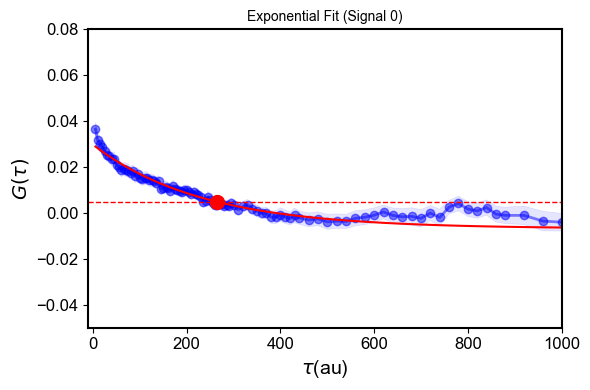

Number of trajectories: 106
Number of cells: 21
-----------------------------------------------------



In [90]:
for dataset in list_datasets:
    df = pd.DataFrame()
    print(f'Processing dataset: {dataset}' '\n') 
    folder_with_files, plot_name, dataframe_prefix = dataset_selection(dataset,control_spots_mode, downsample)
    array_int_all_days, total_number_of_cells, total_number_of_spots = load_tracking_data(folder_with_files, selected_field=selected_field+str(1),
                                                                                        min_percentage_data_in_trajectory=min_percentage_data_in_trajectory,
                                                                                        dataframe_prefix=dataframe_prefix,
                                                                                        smooth_window=smooth_window,
                                                                                        min_snr=min_snr,max_missing_frames=max_missing_frames)
    #plot_data_matrix(array_int_all_days, results_folder, plot_name)
    if downsample:
        primary_data = mi.Utilities().downsample_array(array_int_all_days, factor=downsampling_factor, method='average')
        step_size_in_sec_downsampled = step_size_in_sec * downsampling_factor
    else:
        primary_data = array_int_all_days
        step_size_in_sec_downsampled = step_size_in_sec
    # Temporarily disable parallel processing to avoid module import issues
    with joblib.parallel_backend('threading', n_jobs=1):
        # calculate the ACF
        mean_correlation, std_correlation, lags, correlations_array, dwell_time = mi.Correlation(primary_data=primary_data,
                                                                                            max_lag=None, 
                                                                                            nan_handling= 'forward_fill',  #forward_fill, 'ignore'
                                                                                            shift_data=True,
                                                                                            return_full=False,
                                                                                            time_interval_between_frames_in_seconds=step_size_in_sec_downsampled,
                                                                                            use_bootstrap=True,
                                                                                            show_plot=True,
                                                                                            start_lag=start_lag,
                                                                                            fit_type='exponential',
                                                                                            de_correlation_threshold=0.005,
                                                                                            correct_baseline=True,
                                                                                            use_linear_projection_for_lag_0=True,
                                                                                            save_plots=False,
                                                                                            use_global_mean= False,
                                                                                            remove_outliers = remove_outliers,
                                                                                            MAD_THRESHOLD_FACTOR = MAD_THRESHOLD_FACTOR,
                                                                                            plot_individual_trajectories = False,
                                                                                            y_axes_min_max_list_values = y_axes_min_max_list_values,
                                                                                            x_axes_min_max_list_values = x_axes_min_max_list_values,
                                                                                            multi_tau=multi_tau,
                                                                                            multi_tau_raw_points = multi_tau_raw_points,
                                                                                            multi_tau_bins_per_stage = multi_tau_bins_per_stage,
                                                                                            plot_title=None).run()
    # save all in a single dataframe the rows are each lag, the columns are the mean_correlation, std_correlation, correlations_array, dwell_time
    df = pd.DataFrame(data={'lags': lags, 'mean_correlation': mean_correlation, 'std_correlation': std_correlation})
    df_name ='df_ACF_'+plot_name
    if control_spots_mode:
        df_name = df_name+'_control_spots'
    df.to_csv(results_folder.joinpath(df_name+'.csv'), index=False)
    number_of_trajectories_final = np.shape(correlations_array)[0]
    # write a text file with the results
    file = open(results_folder.joinpath('report_cells_trajectories_ACF_'+plot_name+'.txt'), 'w')
    file.write(f'Total number of cells: {total_number_of_cells}\n')
    file.write(f'Total number of spots: {total_number_of_spots}\n')
    file.write(f'Number of trajectories after filtering based on quality: {number_of_trajectories_final}\n')
    file.close()
    print(f'Number of trajectories: {np.shape(correlations_array)[0]}')
    print(f'Number of cells: {total_number_of_cells}')
    print('-----------------------------------------------------\n')
    #plot_correlation_comparison(mean_correlation, std_correlation, lags, plot_name=plot_name, start_lag=1, show_legend = False, y_axes_min_max_list_values = y_axes_min_max_list_values,x_axes_min_max_list_values=x_axes_min_max_list_values)

In [91]:
# print calculated ke and ki
dwell_time = 300
zero_lag_value = mean_correlation[0]
gene_length = 1900 # in amino acids
# calculate elongation rate is ke = L / dwell_time
ke_calculated = np.round(gene_length / dwell_time, 2)

print(f'Calculated elongation rate ke: {ke_calculated} aa/sec')

# initaiton rate ki = 1/ dwell_time * zero_lag_value
ki_calculated = np.round( 1/ (dwell_time * zero_lag_value), 3)
print(f'Calculated initiation rate ki: {ki_calculated} 1/sec')



Calculated elongation rate ke: 6.33 aa/sec
Calculated initiation rate ki: 0.031 1/sec


In [92]:
#ke_calculated = 10

In [93]:
tag_0_positions = [1, 11, 21, 198, 209, 222, 233, 306, 316, 326]
tag_1_positions = [572, 817, 1062, 1307]

print("-" * 40)
print(f"Tag 1 positions (HA_TAG): {tag_0_positions}")
print(f"Tag 0 positions (GFP_TAG): {tag_1_positions}")
print("-" * 40)

avg_distance = np.mean(tag_1_positions) - np.mean(tag_0_positions)
expected_transit_time = avg_distance / ke_calculated
expected_lag_frames = expected_transit_time / step_size_in_sec
print("-" * 40)
print(f"Expected distance: {avg_distance:.1f} codons")
print(f"Expected transit time: {expected_transit_time:.1f} seconds") 
print("-" * 40)

# calculate this considering the last position of tag 0 and the first position of tag 1
avg_distance_edge = np.min(tag_1_positions) - np.max(tag_0_positions)
expected_transit_time_edge = avg_distance_edge / ke_calculated
expected_lag_frames_edge = expected_transit_time_edge / step_size_in_sec
print("-" * 40)
print(f"Expected distance (edge to edge): {avg_distance_edge:.1f} codons")
print(f"Expected transit time (edge to edge): {expected_transit_time_edge:.1f} seconds")
print("-" * 40)

----------------------------------------
Tag 1 positions (HA_TAG): [1, 11, 21, 198, 209, 222, 233, 306, 316, 326]
Tag 0 positions (GFP_TAG): [572, 817, 1062, 1307]
----------------------------------------
----------------------------------------
Expected distance: 755.2 codons
Expected transit time: 119.3 seconds
----------------------------------------
----------------------------------------
Expected distance (edge to edge): 246.0 codons
Expected transit time (edge to edge): 38.9 seconds
----------------------------------------


Processing dataset: cof

Initial array shape: (50, 360)
SNR filtering: 50 -> 24 trajectories (removed 26 with SNR < 1)
Quality filtering: 24 -> 1 trajectories
Final array shape: (1, 360)
Initial array shape: (17, 335)
SNR filtering: 17 -> 2 trajectories (removed 15 with SNR < 1)
Quality filtering: 2 -> 1 trajectories
Final array shape: (1, 360)
Initial array shape: (47, 360)
SNR filtering: 47 -> 7 trajectories (removed 40 with SNR < 1)
Quality filtering: 7 -> 2 trajectories
Final array shape: (2, 360)
Initial array shape: (44, 360)
SNR filtering: 44 -> 22 trajectories (removed 22 with SNR < 1)
Quality filtering: 22 -> 4 trajectories
Final array shape: (4, 360)
Initial array shape: (24, 360)
SNR filtering: 24 -> 9 trajectories (removed 15 with SNR < 1)
Quality filtering: 9 -> 4 trajectories
Final array shape: (4, 360)
Initial array shape: (52, 360)
SNR filtering: 52 -> 6 trajectories (removed 46 with SNR < 1)
Quality filtering: 6 -> 1 trajectories
Final array shape: (1, 360)
Initial arr

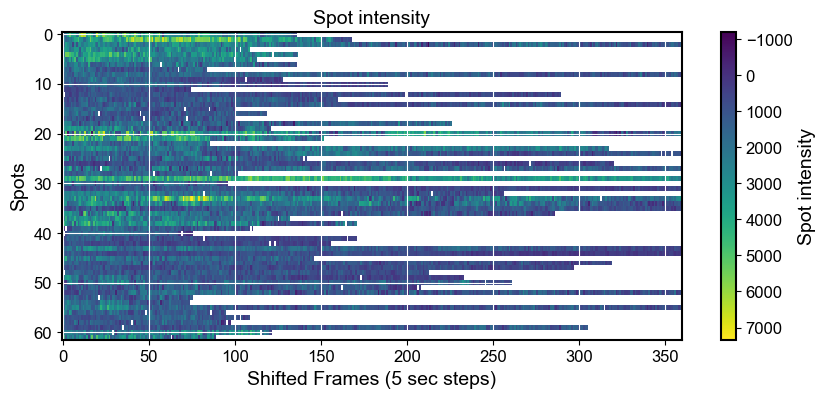

Number of trajectories: 48
Number of cells: 17
-----------------------------------------------------



In [94]:
for dataset in list_datasets:
    df = pd.DataFrame()
    print(f'Processing dataset: {dataset}' '\n') 
    folder_with_files, plot_name, dataframe_prefix = dataset_selection(dataset,control_spots_mode, downsample)
    array_int_all_days, total_number_of_cells, total_number_of_spots = load_tracking_data(folder_with_files, selected_field=selected_field+str(0),
                                                                                          min_percentage_data_in_trajectory=min_percentage_data_in_trajectory,
                                                                                          dataframe_prefix=dataframe_prefix,
                                                                                          smooth_window=smooth_window,
                                                                                          min_snr=min_snr,max_missing_frames=max_missing_frames)
    plot_data_matrix(array_int_all_days, results_folder, plot_name)
    if downsample:
        primary_data = mi.Utilities().downsample_array(array_int_all_days, factor=downsampling_factor, method='average')
        step_size_in_sec_downsampled = step_size_in_sec * downsampling_factor
    else:
        primary_data = array_int_all_days
        step_size_in_sec_downsampled = step_size_in_sec
    # Temporarily disable parallel processing to avoid module import issues
    with joblib.parallel_backend('threading', n_jobs=1):
        # calculate the ACF
        mean_correlation_folding, std_correlation_folding, lags_folding, correlations_array, dwell_time = mi.Correlation(primary_data=primary_data,
                                                                                            max_lag=None, 
                                                                                            nan_handling= 'forward_fill',  #forward_fill, 'ignore'
                                                                                            shift_data=True,
                                                                                            return_full=False,
                                                                                            time_interval_between_frames_in_seconds=step_size_in_sec_downsampled,
                                                                                            use_bootstrap=True,
                                                                                            show_plot=False,
                                                                                            start_lag=start_lag,
                                                                                            fit_type='exponential',
                                                                                            de_correlation_threshold=0.005,
                                                                                            correct_baseline=False,
                                                                                            use_linear_projection_for_lag_0=True,
                                                                                            save_plots=False,
                                                                                            use_global_mean= False,
                                                                                            remove_outliers = remove_outliers,
                                                                                            MAD_THRESHOLD_FACTOR = MAD_THRESHOLD_FACTOR,
                                                                                            plot_individual_trajectories = False,
                                                                                            #y_axes_min_max_list_values = [-0.1,0.1],
                                                                                            #x_axes_min_max_list_values=x_axes_min_max_list_values,
                                                                                            multi_tau=multi_tau,
                                                                                            multi_tau_raw_points = multi_tau_raw_points,
                                                                                            multi_tau_bins_per_stage = multi_tau_bins_per_stage,
                                                                                            plot_title=None).run()
    # save all in a single dataframe the rows are each lag, the columns are the mean_correlation, std_correlation, correlations_array, dwell_time
    df = pd.DataFrame(data={'lags': lags_folding, 'mean_correlation': mean_correlation_folding, 'std_correlation': std_correlation_folding})
    df_name ='df_ACF_'+plot_name
    if control_spots_mode:
        df_name = df_name+'_control_spots'
    df.to_csv(results_folder.joinpath(df_name+'.csv'), index=False)
    number_of_trajectories_final = np.shape(correlations_array)[0]
    # write a text file with the results
    file = open(results_folder.joinpath('report_cells_trajectories_ACF_'+plot_name+'.txt'), 'w')
    file.write(f'Total number of cells: {total_number_of_cells}\n')
    file.write(f'Total number of spots: {total_number_of_spots}\n')
    file.write(f'Number of trajectories after filtering based on quality: {number_of_trajectories_final}\n')
    file.close()
    print(f'Number of trajectories: {np.shape(correlations_array)[0]}')
    print(f'Number of cells: {total_number_of_cells}')
    print('-----------------------------------------------------\n')
    #plot_correlation_comparison(mean_correlation_folding, std_correlation_folding, lags, plot_name=plot_name, start_lag=1, show_legend = False, y_axes_min_max_list_values = None,x_axes_min_max_list_values=x_axes_min_max_list_values)

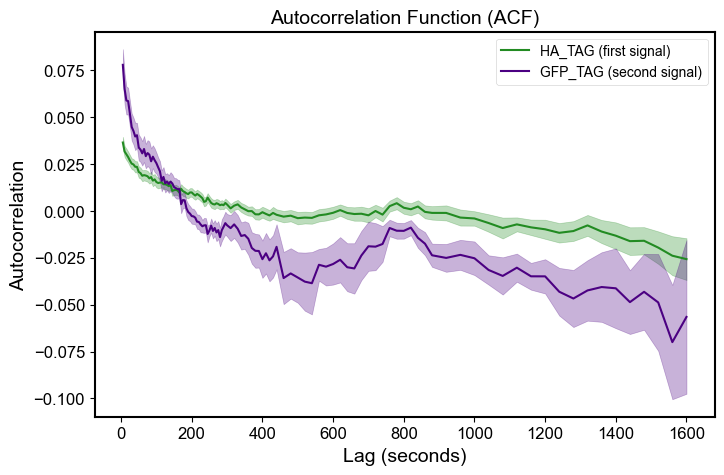

In [95]:
# plot the acf for both signals using matplotlib add starting from lag 1
plt.figure(figsize=(8, 5))
plt.plot(lags[1:], mean_correlation[1:], label='HA_TAG (first signal)', color='forestgreen')
plt.plot(lags_folding[1:], mean_correlation_folding[1:], label='GFP_TAG (second signal)', color='indigo')
plt.fill_between(lags_folding[1:], mean_correlation[1:] - std_correlation[1:], 
                 mean_correlation[1:] + std_correlation[1:], 
                 color='forestgreen', alpha=0.3)
plt.fill_between(lags_folding[1:], mean_correlation_folding[1:] - std_correlation_folding[1:], 
                 mean_correlation_folding[1:] + std_correlation_folding[1:], 
                 color='indigo', alpha=0.3)
plt.xlabel('Lag (seconds)')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF)')
plt.legend()
plt.grid()
plt.show()

In [96]:
def extract_dual_channel_data(dataframe, primary_field, secondary_field, 
                             min_percentage_data_in_trajectory=0.3, 
                             max_missing_frames=5, min_snr=1, maximum_columns=360, use_forward_fill=True,
                             smooth_window=1):
    """
    Extract synchronized dual-channel intensity data with proper filtering.
    """
    # Extract raw arrays for both channels
    primary_raw = mi.Utilities().df_trajectories_to_array(
        dataframe=dataframe, selected_field=primary_field, fill_value='nans')
    secondary_raw = mi.Utilities().df_trajectories_to_array(
        dataframe=dataframe, selected_field=secondary_field, fill_value='nans')
    
    # Validate same number of trajectories
    if primary_raw.shape[0] != secondary_raw.shape[0]:
        print(f"    WARNING: Channel shape mismatch - Primary: {primary_raw.shape}, Secondary: {secondary_raw.shape}")
        return None, None
    
    # Extract SNR data for filtering (use channel 1 SNR as reference)
    try:
        snr_array = mi.Utilities().df_trajectories_to_array(
            dataframe=dataframe, selected_field='snr_ch_1', fill_value='nans')
        mean_snr_array = np.nanmean(snr_array, axis=1)
        
        # Apply SNR filter to both channels simultaneously
        snr_mask = mean_snr_array >= min_snr
        primary_filtered = primary_raw[snr_mask, :]
        secondary_filtered = secondary_raw[snr_mask, :]
        
        print(f"    SNR filtering: {primary_raw.shape[0]} -> {primary_filtered.shape[0]} trajectories")
        
    except Exception as e:
        print(f"    WARNING: SNR filtering failed ({e}), using all trajectories")
        primary_filtered = primary_raw
        secondary_filtered = secondary_raw
    
    # ===== PRE-FILTER: Quality check on BOTH channels BEFORE shift_trajectories =====
    n_time = primary_filtered.shape[1]
    max_nans_allowed = int(round(n_time * (1 - min_percentage_data_in_trajectory)))
    
    # Count NaNs in BOTH channels
    primary_nan_counts = np.isnan(primary_filtered).sum(axis=1)
    secondary_nan_counts = np.isnan(secondary_filtered).sum(axis=1)
    
    # Keep only trajectories where BOTH channels meet the threshold
    quality_mask = (primary_nan_counts <= max_nans_allowed) & (secondary_nan_counts <= max_nans_allowed)
    
    primary_filtered = primary_filtered[quality_mask, :]
    secondary_filtered = secondary_filtered[quality_mask, :]
    
    print(f"    Pre-quality filtering (BOTH channels): {primary_nan_counts.shape[0]} -> {primary_filtered.shape[0]} trajectories")
    
    if primary_filtered.shape[0] == 0:
        print(f"    ERROR: No trajectories passed dual-channel quality filter")
        return None, None
    
    # Now call shift_trajectories with pre-filtered data
    try:
        primary_shifted, secondary_shifted = mi.Utilities().shift_trajectories(
            array_ch0=primary_filtered,
            array_ch1=secondary_filtered,
            min_percentage_data_in_trajectory=min_percentage_data_in_trajectory,
            max_missing_frames=max_missing_frames
        )
        print(f"    Shift/alignment: {primary_filtered.shape[0]} -> {primary_shifted.shape[0]} trajectories")
    except Exception as e:
        print(f"    ERROR: Shifting failed ({e})")
        return None, None
    # USE FORWARD FILL TO HANDLE NaNs
    if use_forward_fill:
        primary_shifted = mi.Utilities().forward_fill_nan_2d(primary_shifted)
        secondary_shifted = mi.Utilities().forward_fill_nan_2d(secondary_shifted)
        print(f"    Applied forward-fill to handle NaNs")

    
    # Validate final shapes match
    if primary_shifted.shape != secondary_shifted.shape:
        print(f"    ERROR: Final shape mismatch - Primary: {primary_shifted.shape}, Secondary: {secondary_shifted.shape}")
        return None, None
    
    # Handle padding/truncation
    number_of_columns = primary_shifted.shape[1]
    if number_of_columns < maximum_columns:
        pad_width = maximum_columns - number_of_columns
        primary_shifted = np.pad(primary_shifted, ((0,0), (0, pad_width)), 
                               mode='constant', constant_values=np.nan)
        secondary_shifted = np.pad(secondary_shifted, ((0,0), (0, pad_width)), 
                                 mode='constant', constant_values=np.nan)
    elif number_of_columns > maximum_columns:
        primary_shifted = primary_shifted[:, :maximum_columns]
        secondary_shifted = secondary_shifted[:, :maximum_columns]
    
    # ===== POST-PADDING QUALITY CHECK (before smoothing) =====
    # Re-check quality after padding to ensure no mostly-NaN trajectories snuck through
    primary_valid_counts = np.sum(np.isfinite(primary_shifted), axis=1)
    secondary_valid_counts = np.sum(np.isfinite(secondary_shifted), axis=1)
    
    # Require at least min_percentage_data_in_trajectory valid points in BOTH channels
    min_valid_points = int(round(maximum_columns * min_percentage_data_in_trajectory))
    
    final_quality_mask = (primary_valid_counts >= min_valid_points) & (secondary_valid_counts >= min_valid_points)
    
    primary_shifted = primary_shifted[final_quality_mask, :]
    secondary_shifted = secondary_shifted[final_quality_mask, :]
    
    n_removed_post_padding = np.sum(~final_quality_mask)
    if n_removed_post_padding > 0:
        print(f"    Post-padding quality check: removed {n_removed_post_padding} trajectories with <{min_valid_points} valid points")
    
    if primary_shifted.shape[0] == 0:
        print(f"    ERROR: No trajectories passed final quality check")
        return None, None
    
    # Apply smoothing ONLY AFTER final quality check
    if smooth_window > 1:
        primary_shifted = uniform_filter1d(primary_shifted, size=smooth_window, axis=1, mode='nearest')
        secondary_shifted = uniform_filter1d(secondary_shifted, size=smooth_window, axis=1, mode='nearest')
        print(f"    Applied smoothing with window size: {smooth_window}")

    print(f"    Final synchronized shapes: {primary_shifted.shape}")
    
    return primary_shifted, secondary_shifted

In [97]:
def load_dual_channel_tracking_data(root_folder: Path, base_field: str, min_percentage_data_in_trajectory=0.3, dataframe_prefix='tracking_',min_snr=1,max_missing_frames=5):
    """
    Load and process dual-channel tracking data ensuring synchronized trajectories.
    
    Parameters:
    -----------
    base_field : str
        Base field name (e.g., 'spot_int_ch')
    
    Returns:
    --------
    primary_data, secondary_data : arrays
        Synchronized data arrays with same number of trajectories
    """
    # Get tracking files
    subfolders = [folder for folder in root_folder.iterdir() if folder.is_dir() and 'results_' in folder.name]
    tracking_files = [file 
                      for folder in subfolders 
                      for file in folder.iterdir() 
                      if dataframe_prefix in file.name and file.suffix.lower() == '.csv']
    
    primary_arrays = []
    secondary_arrays = []
    total_files_processed = 0
    
    print(f"Processing {len(tracking_files)} files for dual-channel analysis...")
    
    for tracking_file in tracking_files:
        try:
            df = pd.read_csv(tracking_file)
            print(f"\nProcessing: {tracking_file.name}")
            
            # Extract both channels simultaneously
            primary_field = base_field + '1' # spot_int_ch_1 HA_TAG
            secondary_field = base_field + '0' # spot_int_ch_1 for GFP_TAG
            
            # Check if both fields exist
            print(f"  Checking for fields: {primary_field}, {secondary_field}"  )
            if primary_field not in df.columns or secondary_field not in df.columns:
                print(f"  SKIP: Missing channels. Available: {[col for col in df.columns if 'spot_int_ch' in col]}")
                continue
            
            # Extract synchronized data
            primary_array, secondary_array = extract_dual_channel_data(
                df, 
                primary_field=primary_field,
                secondary_field=secondary_field,
                min_percentage_data_in_trajectory=min_percentage_data_in_trajectory,
                min_snr=min_snr,
                max_missing_frames=max_missing_frames,
                smooth_window=smooth_window,
            )
            
            if primary_array is not None and secondary_array is not None:
                primary_arrays.append(primary_array)
                secondary_arrays.append(secondary_array)
                total_files_processed += 1
                print(f"  SUCCESS: {primary_array.shape[0]} synchronized trajectories")
            else:
                print(f"  SKIP: No valid synchronized trajectories")
                
        except Exception as e:
            print(f"  ERROR: {e}")
    
    if not primary_arrays:
        raise ValueError(f"No valid dual-channel data found in {len(tracking_files)} files")
    
    # Concatenate all arrays
    primary_concatenated = np.concatenate(primary_arrays, axis=0)
    secondary_concatenated = np.concatenate(secondary_arrays, axis=0)
    
    print(f"\n=== SUMMARY ===")
    print(f"Files processed: {total_files_processed}/{len(tracking_files)}")
    print(f"Final primary shape: {primary_concatenated.shape}")
    print(f"Final secondary shape: {secondary_concatenated.shape}")
    print(f"Total synchronized trajectories: {primary_concatenated.shape[0]}")
    
    return primary_concatenated, secondary_concatenated, total_files_processed



In [98]:
primary_data, secondary_data, total_number_of_cells = load_dual_channel_tracking_data(
    folder_with_files, 
    base_field=selected_field,
    min_percentage_data_in_trajectory=min_percentage_data_in_trajectory,
    dataframe_prefix=dataframe_prefix,
    min_snr=min_snr,
    max_missing_frames=max_missing_frames
)

Processing 22 files for dual-channel analysis...

Processing: tracking_20250912 pRS027_057_012 ON Tfx-1_Series018.csv
  Checking for fields: spot_int_ch_1, spot_int_ch_0
    SNR filtering: 50 -> 43 trajectories
    Pre-quality filtering (BOTH channels): 43 -> 13 trajectories
    Shift/alignment: 13 -> 2 trajectories
    Applied forward-fill to handle NaNs
    Final synchronized shapes: (2, 360)
  SUCCESS: 2 synchronized trajectories

Processing: tracking_20250912 pRS027_057_012 ON Tfx-1_Series017.csv
  Checking for fields: spot_int_ch_1, spot_int_ch_0
    SNR filtering: 17 -> 17 trajectories
    Pre-quality filtering (BOTH channels): 17 -> 3 trajectories
    Shift/alignment: 3 -> 1 trajectories
    Applied forward-fill to handle NaNs
    Final synchronized shapes: (1, 360)
  SUCCESS: 1 synchronized trajectories

Processing: tracking_20251002 pRS027_012_061 _3 ON Tfx-1_Series001.csv
  Checking for fields: spot_int_ch_1, spot_int_ch_0
    SNR filtering: 47 -> 47 trajectories
    Pre-qual

Processing dataset: cof

Processing 22 files for dual-channel analysis...

Processing: tracking_20250912 pRS027_057_012 ON Tfx-1_Series018.csv
  Checking for fields: spot_int_ch_1, spot_int_ch_0
    SNR filtering: 50 -> 43 trajectories
    Pre-quality filtering (BOTH channels): 43 -> 13 trajectories
    Shift/alignment: 13 -> 2 trajectories
    Applied forward-fill to handle NaNs
    Final synchronized shapes: (2, 360)
  SUCCESS: 2 synchronized trajectories

Processing: tracking_20250912 pRS027_057_012 ON Tfx-1_Series017.csv
  Checking for fields: spot_int_ch_1, spot_int_ch_0
    SNR filtering: 17 -> 17 trajectories
    Pre-quality filtering (BOTH channels): 17 -> 3 trajectories
    Shift/alignment: 3 -> 1 trajectories
    Applied forward-fill to handle NaNs
    Final synchronized shapes: (1, 360)
  SUCCESS: 1 synchronized trajectories

Processing: tracking_20251002 pRS027_012_061 _3 ON Tfx-1_Series001.csv
  Checking for fields: spot_int_ch_1, spot_int_ch_0
    SNR filtering: 47 -> 47 

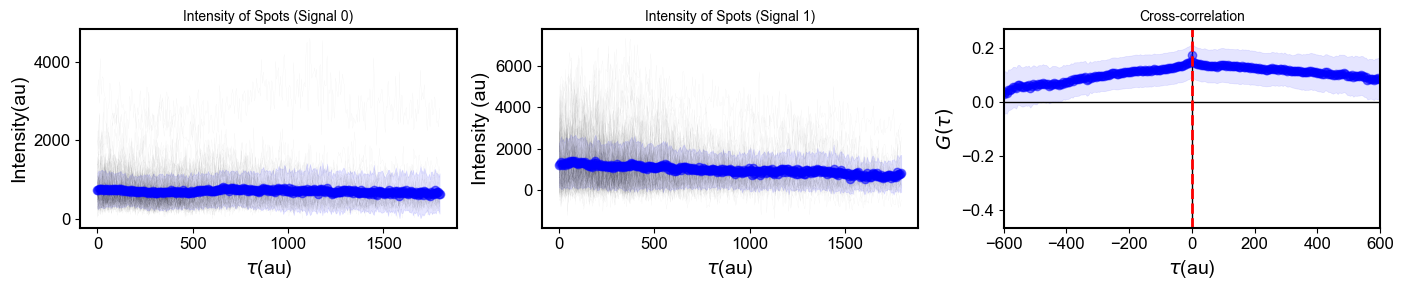

Final synchronized trajectories: 125
Number of cells: 21
-----------------------------------------------------



In [99]:
for dataset in list_datasets:
    df = pd.DataFrame()
    print(f'Processing dataset: {dataset}' '\n') 
    folder_with_files, plot_name, dataframe_prefix = dataset_selection(dataset, control_spots_mode, downsample)
    #selected_field = 'spot_int_ch'  # Base field name
    # Load synchronized dual-channel data
    primary_data, secondary_data, total_number_of_cells = load_dual_channel_tracking_data(
        folder_with_files, 
        base_field=selected_field,
        min_percentage_data_in_trajectory=min_percentage_data_in_trajectory,
        dataframe_prefix=dataframe_prefix,
        min_snr=min_snr,
        max_missing_frames=max_missing_frames
    )
    total_number_of_spots = primary_data.shape[0]
    print(f"Synchronized data shapes:")
    print(f"  Primary (ch_1): {primary_data.shape}")
    print(f"  Secondary (ch_0): {secondary_data.shape}")
    # Proceed with cross-correlation analysis
    with joblib.parallel_backend('threading', n_jobs=1):
        mean_correlation, std_correlation, lags, correlations_array, dwell_time = mi.Correlation(
            primary_data=primary_data,
            secondary_data=secondary_data,
            max_lag=None, 
            nan_handling='forward_fill',
            shift_data=True,
            return_full=True,
            time_interval_between_frames_in_seconds=step_size_in_sec,
            use_bootstrap=True,
            show_plot=True,
            start_lag=start_lag,
            fit_type='exponential',
            de_correlation_threshold=0.005,
            correct_baseline=False,
            use_linear_projection_for_lag_0=False,
            save_plots=False,
            use_global_mean=True,
            remove_outliers=False,
            MAD_THRESHOLD_FACTOR=MAD_THRESHOLD_FACTOR,
            plot_individual_trajectories=False,
            x_axes_min_max_list_values=[-600,600],
            multi_tau=False,
            plot_title=None
        ).run()
    # Save results
    df = pd.DataFrame(data={'lags': lags, 'mean_correlation': mean_correlation, 'std_correlation': std_correlation})
    df_name = 'df_CrossCorr_' + plot_name
    if control_spots_mode:
        df_name = df_name + '_control_spots'
    df.to_csv(results_folder.joinpath(df_name + '.csv'), index=False)
    # Write report
    number_of_trajectories_final = np.shape(correlations_array)[0]
    file = open(results_folder.joinpath('report_crosscorr_' + plot_name + '.txt'), 'w')
    file.write(f'Total number of cells: {total_number_of_cells}\n')
    file.write(f'Total number of synchronized spots: {total_number_of_spots}\n')
    file.write(f'Number of trajectories after all filtering: {number_of_trajectories_final}\n')
    file.close()
    print(f'Final synchronized trajectories: {number_of_trajectories_final}')
    print(f'Number of cells: {total_number_of_cells}')
    print('-----------------------------------------------------\n')

Flat plateau detected: 5 points, using center at lag 0.0 s
Plateau tolerance: 2.0%, corresponds to 0.003 units below peak value 0.146
Plateau lag range: -10.0 s to 10.0 s


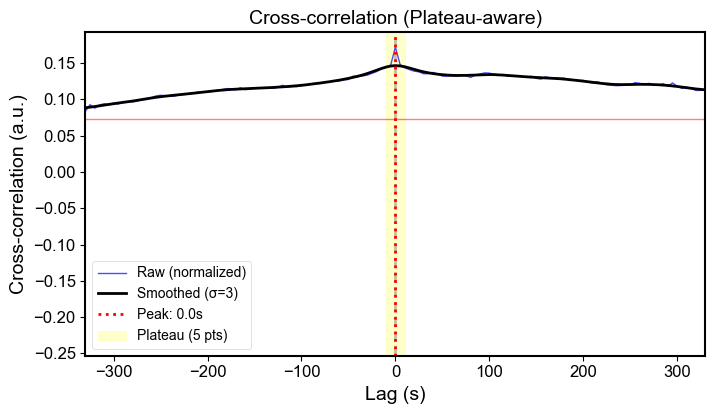

In [100]:
def analyze_crosscorr(
    corr,
    dt=5.0,
    lags_s=None,
    zero_index=None,
    window_s=600.0,
    slope_window_pts=3,
    halfmax_fraction=0.5,
    plot=False,
    ax=None,
    plateau_tolerance=0.02,  # New parameter for plateau detection
    sigma_smooth=1,  # Added sigma_smooth parameter
    min_max_normalize=True,  # New parameter for min-max normalization
    axis_lims =None,  # New parameter for axis limits
):
    """
    Analyze a cross-correlation curve to extract delay/shape metrics.
    Now handles flat plateaus by finding the center.
    
    Parameters
    ----------
    corr : (N,) array
        Cross-correlation values vs. lag. Can contain NaNs.
    dt : float, default 5.0
        Sampling interval (seconds per frame).
    lags_s : (N,) array or None
        Lag axis in seconds. If None, built from dt.
    zero_index : int or None
        Index corresponding to lag = 0 s. Defaults to N//2.
    window_s : float, default 600.0
        Time window (±window_s) for area-asymmetry calculation.
    slope_window_pts : int, default 3
        Number of points on each side of 0-lag for local slope fits.
    halfmax_fraction : float, default 0.5
        Fraction of peak for "dominant range" threshold.
    plot : bool, default False
        If True, plots the correlation and annotations.
    ax : matplotlib.axes.Axes or None
        Existing axis to plot into.
    plateau_tolerance : float, default 0.02
        Tolerance for plateau detection (2% below peak).
    sigma_smooth : float, default 1
        Standard deviation for Gaussian smoothing of correlation.
    min_max_normalize : bool, default True
        If True, normalize corr to [0, 1] range based on window_s range.
    """
    corr = np.asarray(corr).astype(float).squeeze()
    if corr.ndim != 1:
        raise ValueError(f"corr must be 1D, got shape {corr.shape}")

    N = len(corr)

    # Build lag axis if not provided
    if lags_s is None:
        if zero_index is None:
            zero_index = N // 2
        lags_frames = np.arange(N) - int(zero_index)
        lags_s = lags_frames * float(dt)
    else:
        lags_s = np.asarray(lags_s).astype(float).squeeze()
        if lags_s.shape != corr.shape:
            raise ValueError("lags_s must have same shape as corr")

    # Interpolate NaNs linearly for stable metrics/plotting
    finite = np.isfinite(corr)
    corr_interp = corr.copy()
    if not np.all(finite):
        good = np.where(finite)[0]
        bad = np.where(~finite)[0]
        if good.size == 0:
            raise ValueError("corr contains no finite values")
        corr_interp[bad] = np.interp(bad, good, corr[good])

    # Apply min-max normalization using ONLY the windowed region
    # Define the window mask
    mask = (lags_s >= -window_s) & (lags_s <= window_s)
    # Find min/max ONLY within the window
    windowed_data = corr_interp[mask]
    corr_min = np.min(windowed_data)
    corr_max = np.max(windowed_data)
    
    if min_max_normalize:    
        #print(f"Normalization window: ±{window_s} s ({np.sum(mask)} points)")
        print(f"Window range: [{corr_min:.4f}, {corr_max:.4f}]")
        
        if corr_max > corr_min:
            # Apply normalization to entire array using window min/max
            corr_interp = (corr_interp - corr_min) / (corr_max - corr_min)
            print(f"Min-max normalization applied to entire array using window range")
        else:
            # All values in window are the same
            corr_interp = corr_interp - corr_min
            print(f"Warning: Constant correlation values in window, centering at zero")

    # Apply Gaussian smoothing
    corr_smooth = gaussian_filter1d(corr_interp, sigma=sigma_smooth)

    # Peak finding: handle flat plateaus by finding center
    global_max_val = float(np.max(corr_smooth))
    threshold = global_max_val * (1.0 - plateau_tolerance)
    
    # Find all points in plateau
    plateau_mask = corr_smooth >= threshold
    plateau_indices = np.where(plateau_mask)[0]
    
    if len(plateau_indices) > 1:
        # Find center of plateau
        peak_idx = plateau_indices[len(plateau_indices) // 2]
        print(f"Flat plateau detected: {len(plateau_indices)} points, using center at lag {lags_s[peak_idx]:.1f} s")
        print(f"Plateau tolerance: {plateau_tolerance*100:.1f}%, corresponds to {global_max_val*plateau_tolerance:.3f} units below peak value {global_max_val:.3f}")
        print(f"Plateau lag range: {lags_s[plateau_indices[0]]:.1f} s to {lags_s[plateau_indices[-1]]:.1f} s")
    else:
        # Single peak
        peak_idx = plateau_indices[0]

    peak_val = float(corr_smooth[peak_idx])
    peak_lag = float(lags_s[peak_idx])

    # Weighted centroid (shift corr to be nonnegative)
    y_shift = corr_smooth - np.min(corr_smooth)
    denom = y_shift.sum()
    centroid = float(np.sum(lags_s * y_shift) / denom) if denom > 0 else np.nan

    # Half-maximum crossings & FWHM (linear interpolation) - use smoothed data
    def _halfmax_crossings(x, y, frac=0.5):
        p = int(np.argmax(y))
        pk = float(y[p])
        hm = frac * pk
        left_x = np.nan
        for i in range(p, 0, -1):
            y1, y2 = y[i-1], y[i]
            if (y1 - hm) * (y2 - hm) <= 0:
                x1, x2 = x[i-1], x[i]
                left_x = x1 if y2 == y1 else x1 + (hm - y1) * (x2 - x1) / (y2 - y1)
                break
        right_x = np.nan
        for i in range(p, len(y)-1):
            y1, y2 = y[i], y[i+1]
            if (y1 - hm) * (y2 - hm) <= 0:
                x1, x2 = x[i], x[i+1]
                right_x = x2 if y2 == y1 else x1 + (hm - y1) * (x2 - x1) / (y2 - y1)
                break
        width = float(right_x - left_x) if np.isfinite(left_x) and np.isfinite(right_x) else np.nan
        return width, left_x, right_x

    FWHM, left_hm, right_hm = _halfmax_crossings(lags_s, corr_smooth, frac=0.5)

    # Dominant range at specified fraction (contiguous region around peak above threshold)
    def _dominant_range(x, y, frac=0.5):
        p = int(np.argmax(y))
        thresh = frac * float(y[p])
        L = p
        while L-1 >= 0 and y[L-1] >= thresh:
            L -= 1
        R = p
        while R+1 < len(y) and y[R+1] >= thresh:
            R += 1
        return float(x[L]), float(x[R])

    dom_left, dom_right = _dominant_range(lags_s, corr_smooth, frac=halfmax_fraction)

    # Local slopes at 0 (least-squares line fits on small neighborhoods) - use smoothed data
    idx0 = int(np.argmin(np.abs(lags_s - 0.0)))
    L_slice = slice(max(0, idx0 - slope_window_pts), idx0 + 1)
    R_slice = slice(idx0, min(N, idx0 + slope_window_pts + 1))

    def _fit_slope(x, y):
        if len(x) < 2:
            return np.nan
        A = np.vstack([x, np.ones_like(x)]).T
        m, _ = np.linalg.lstsq(A, y, rcond=None)[0]
        return float(m)

    slope_left = _fit_slope(lags_s[L_slice], corr_smooth[L_slice])
    slope_right = _fit_slope(lags_s[R_slice], corr_smooth[R_slice])

    # Area asymmetry in ±window_s (only positive parts) - use smoothed data
    step = float(np.median(np.diff(lags_s)))
    wmask = np.abs(lags_s) <= float(window_s)
    xw = lags_s[wmask]
    yw = corr_smooth[wmask]
    pos_area = float(np.sum(np.clip(yw[xw > 0], 0, None)) * step) if np.any(xw > 0) else 0.0
    neg_area = float(np.sum(np.clip(yw[xw < 0], 0, None)) * step) if np.any(xw < 0) else 0.0
    asym = (pos_area - neg_area) / (pos_area + neg_area + 1e-12)

    metrics = {
        "n_points": N,
        "dt_seconds": float(dt),
        "peak_lag_seconds": peak_lag,
        "peak_value": peak_val,
        "centroid_lag_seconds": centroid,
        "FWHM_seconds": FWHM,
        "FWHM_left_crossing_seconds": left_hm,
        "FWHM_right_crossing_seconds": right_hm,
        "slope_left_at_0_per_s": slope_left,
        "slope_right_at_0_per_s": slope_right,
        "area_asymmetry_pm_window": asym,
        "dominant_left_seconds": dom_left,
        "dominant_right_seconds": dom_right,
    }

    if plot:
        import matplotlib.pyplot as plt
        if ax is None:
            _, ax = plt.subplots(figsize=(8, 4.2))
        
        # Plot both raw and smoothed correlations
        ax.plot(lags_s, corr_interp, lw=1, color="blue", alpha=0.7, label="Raw (normalized)")
        # plot the corrected line, removing the time point where the lag values are 0.

        

        ax.plot(lags_s, corr_smooth, lw=2, color="k", label=f"Smoothed (σ={sigma_smooth})")
        
        ax.axvline(0, ls="--", lw=2, color="gray", alpha=0.5)
        ax.axvline(peak_lag, ls=":", lw=2, color="red", label=f"Peak: {peak_lag:.1f}s")
        
        # Highlight plateau region
        if len(plateau_indices) > 1:
            ax.axvspan(lags_s[plateau_indices[0]], lags_s[plateau_indices[-1]], 
                      alpha=0.2, color="yellow", label=f"Plateau ({len(plateau_indices)} pts)")
        
        # Plot FWHM markers
        if np.isfinite(FWHM):
            ax.axvline(left_hm, ls="-", lw=1, color="red", alpha=0.5)
            ax.axvline(right_hm, ls="-", lw=1, color="red", alpha=0.5)
            ax.hlines(halfmax_fraction * peak_val, left_hm, right_hm, color="red", lw=1, alpha=0.5)
        
        # Set plot limits
        if np.isfinite(window_s):
            ax.set_xlim(-1.1 * window_s, 1.1 * window_s)
        
        # if min_max_normalize:
        #     # For normalized data, show a bit beyond [0,1] for context
        #     y_min, y_max = ax.get_ylim()
        #     #ax.set_ylim(-0.05, 1.05)
        #     #ax.set_ylim(min(-0.1, y_min), max(1.1, y_max))
        # else:
        #     #ax.set_ylim(corr_min, corr_max)
        #     ax.set_ylim(0, 0.04)
        if axis_lims is not None:
            ax.set_ylim(axis_lims)

        ax.set_title("Cross-correlation (Plateau-aware)")
        ax.set_xlabel("Lag (s)")
        ax.set_ylabel("Cross-correlation (normalized)" if min_max_normalize else "Cross-correlation (a.u.)")
        ax.legend()
        ax.grid(True, alpha=0.2)

        # y lims

        
        if ax is None:
            plt.tight_layout()
            plt.show()

    return metrics, corr_interp, lags_s


# Updated function call with sigma_smooth parameter
max_lag_selected = 300
metrics, corr_interp, lags_s = analyze_crosscorr(
    mean_correlation, 
    dt=step_size_in_sec, 
    plot=True, 
    window_s=max_lag_selected, 
    slope_window_pts=1, 
    halfmax_fraction=0.5, 
    plateau_tolerance=0.02,
    sigma_smooth=3,  # Add smoothing parameter
    min_max_normalize=False,  # Add normalization parameter
    #axis_lims=(0, 0.055)  # Set y-axis limits
    #axis_lims=(0, 0.02)
)



In [101]:
raise NotImplementedError("This is a code snippet for analysis; please integrate into your workflow.")


NotImplementedError: This is a code snippet for analysis; please integrate into your workflow.